À partir des données nous essaierons de répondre à 2 problématiques :



Comment prédire le comportement du consomateur ?


Comment optimiser les ventes ?

In [3]:
import pandas as pd
orders = pd.read_csv("../data/raw/orders.csv")
orders.head()

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1.0,1.0,2.0,8.0,NaN
1,2398795,1.0,2.0,3.0,7.0,15.0
2,473747,1.0,3.0,3.0,12.0,21.0
3,2254736,1.0,4.0,4.0,7.0,29.0
4,431534,1.0,5.0,4.0,15.0,28.0


In [4]:
order_products = pd.read_csv("../data/raw/order_products.csv")
order_products.head()

,order_id,product_id,add_to_cart_order,reordered
0,2,33120.0,1.0,1.0
1,2,28985.0,2.0,1.0
2,2,9327.0,3.0,0.0
3,2,45918.0,4.0,1.0
4,2,30035.0,5.0,0.0


In [5]:
products = pd.read_csv("../data/raw/products.csv")
products.head()

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [6]:
aisles = pd.read_csv("../data/raw/aisles.csv")
aisles.head()

,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


In [7]:
departments = pd.read_csv("../data/raw/departments.csv")

departments.head()

,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


In [8]:
df_nextBuy = order_products.merge(orders, on="order_id", how = "left")

In [9]:
df_nextBuy.head()

,order_id,product_id,add_to_cart_order,reordered,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2,33120.0,1.0,1.0,202279.0,3.0,5.0,9.0,8.0
1,2,28985.0,2.0,1.0,202279.0,3.0,5.0,9.0,8.0
2,2,9327.0,3.0,0.0,202279.0,3.0,5.0,9.0,8.0
3,2,45918.0,4.0,1.0,202279.0,3.0,5.0,9.0,8.0
4,2,30035.0,5.0,0.0,202279.0,3.0,5.0,9.0,8.0


In [10]:
df_nextBuy = df_nextBuy.merge(products, on = "product_id", how = "left")
df_nextBuy.head()

,order_id,product_id,add_to_cart_order,reordered,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id
0,2,33120.0,1.0,1.0,202279.0,3.0,5.0,9.0,8.0,Organic Egg Whites,86.0,16.0
1,2,28985.0,2.0,1.0,202279.0,3.0,5.0,9.0,8.0,Michigan Organic Kale,83.0,4.0
2,2,9327.0,3.0,0.0,202279.0,3.0,5.0,9.0,8.0,Garlic Powder,104.0,13.0
3,2,45918.0,4.0,1.0,202279.0,3.0,5.0,9.0,8.0,Coconut Butter,19.0,13.0
4,2,30035.0,5.0,0.0,202279.0,3.0,5.0,9.0,8.0,Natural Sweetener,17.0,13.0


In [11]:
df_nextBuy = df_nextBuy.merge(aisles, on = "aisle_id", how = "left")
df_nextBuy.head()


,order_id,product_id,add_to_cart_order,reordered,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle
0,2,33120.0,1.0,1.0,202279.0,3.0,5.0,9.0,8.0,Organic Egg Whites,86.0,16.0,eggs
1,2,28985.0,2.0,1.0,202279.0,3.0,5.0,9.0,8.0,Michigan Organic Kale,83.0,4.0,fresh vegetables
2,2,9327.0,3.0,0.0,202279.0,3.0,5.0,9.0,8.0,Garlic Powder,104.0,13.0,spices seasonings
3,2,45918.0,4.0,1.0,202279.0,3.0,5.0,9.0,8.0,Coconut Butter,19.0,13.0,oils vinegars
4,2,30035.0,5.0,0.0,202279.0,3.0,5.0,9.0,8.0,Natural Sweetener,17.0,13.0,baking ingredients


In [12]:
df_nextBuy = df_nextBuy.merge(departments, on = "department_id", how = "left")
df_nextBuy.head()

,order_id,product_id,add_to_cart_order,reordered,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,2,33120.0,1.0,1.0,202279.0,3.0,5.0,9.0,8.0,Organic Egg Whites,86.0,16.0,eggs,dairy eggs
1,2,28985.0,2.0,1.0,202279.0,3.0,5.0,9.0,8.0,Michigan Organic Kale,83.0,4.0,fresh vegetables,produce
2,2,9327.0,3.0,0.0,202279.0,3.0,5.0,9.0,8.0,Garlic Powder,104.0,13.0,spices seasonings,pantry
3,2,45918.0,4.0,1.0,202279.0,3.0,5.0,9.0,8.0,Coconut Butter,19.0,13.0,oils vinegars,pantry
4,2,30035.0,5.0,0.0,202279.0,3.0,5.0,9.0,8.0,Natural Sweetener,17.0,13.0,baking ingredients,pantry


Graphic of orders per hour

In [ ]:
#Prepare Data 
orders_per_hour = (
    df_nextBuy
    .groupby("order_hour_of_day")["order_id"]
    .nunique()
    .reset_index(name="num_orders")
)


In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

In [25]:
plt.figure(figsize=(10,5))

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

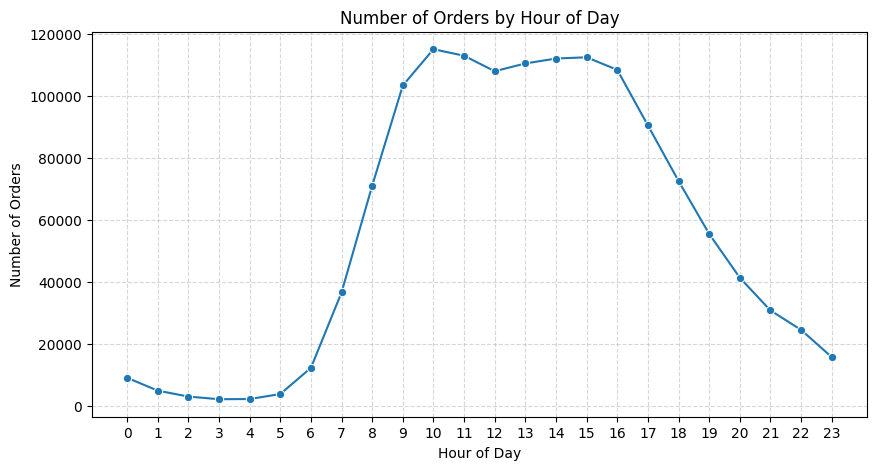

In [26]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=orders_per_hour,
    x="order_hour_of_day",
    y="num_orders",
    marker="o"
)

plt.title("Number of Orders by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")

plt.xticks(range(0,24))
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

Observation:

Le graphique montre que en moyenne à partir de  6 heure du matin les commandes augmentent, cela continue de manière exponentielle jusqu'à un pic à 10h, puis on on observe une stagnation jusqu'à 17h:
À partir de 17h on observe une baisse jusqu'à 4h du matin.
On peut ce demander si cela est le cas pour tout les jour

Quel sont les Jours on l'on fait le plus de vente

In [27]:
#Data preparation
orders_per_day = (
    df_nextBuy
    .groupby("order_dow")["order_id"]
    .nunique()
    .reset_index(name="num_orders")
)

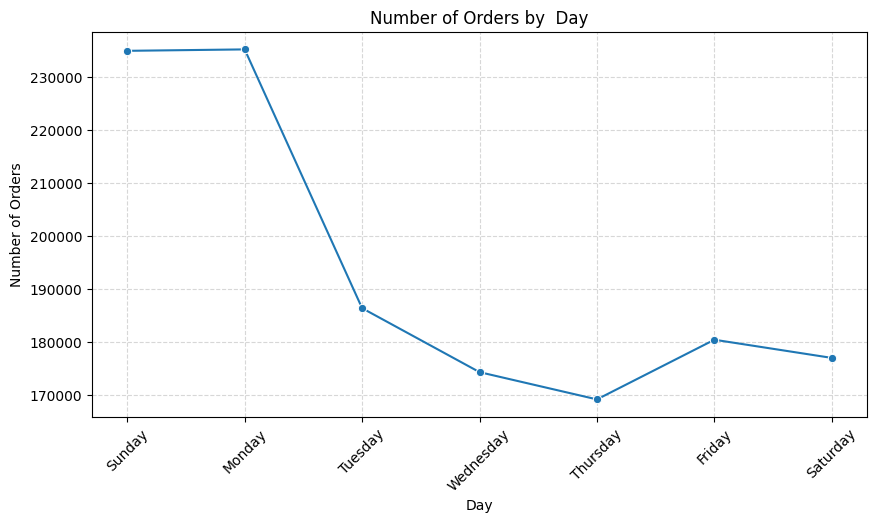

In [28]:
#Create the Graphic
days = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]

plt.figure(figsize=(10,5))

sns.lineplot(
    data=orders_per_day,
    x="order_dow",
    y="num_orders",
    marker="o"
)

plt.title("Number of Orders by  Day")
plt.xlabel("Day")
plt.ylabel("Number of Orders")

plt.xticks(ticks=range(0,7), labels=days, rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

Observation

Les jours où il y'a le plus de commande sont les dimanche
et lundi.

Do customers order differently on certain days of the week?

Sunday

In [ ]:
#Prepare Data (Sunday per hour)
df_sunday = df_nextBuy[df_nextBuy["order_dow"] == 0]
orders_sunday_hour = (
    df_sunday
    .groupby("order_hour_of_day")["order_id"]
    .nunique()
    .reset_index(name="num_orders")
)

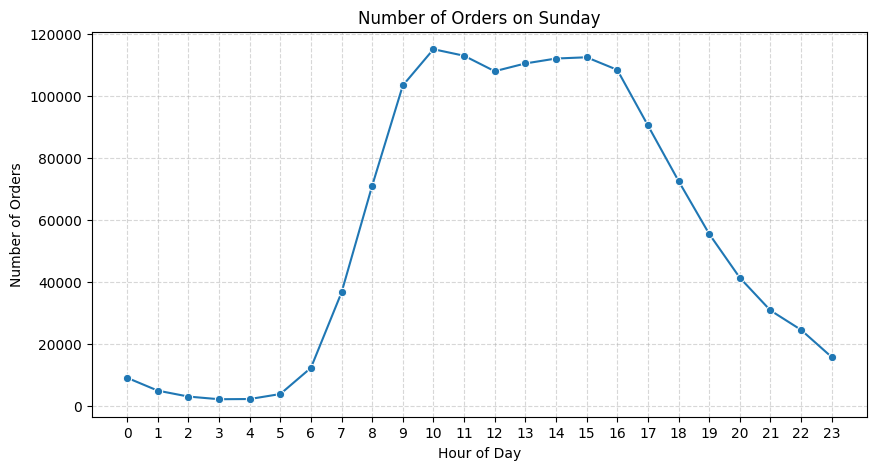

In [ ]:
#The Graphic (Sunday per hour)
plt.figure(figsize=(10,5))

sns.lineplot(
    data=orders_per_hour,
    x="order_hour_of_day",
    y="num_orders",
    marker="o"
)

plt.title("Number of Orders on Sunday")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")

plt.xticks(range(0,24))
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

Quels sont les département far: